# Part 3: Customer Churn Prediction Model

Author: Prateek Parmar

In [66]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import pickle
import json

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [67]:
# Load Datasets

customers = pd.read_csv("../d2c churn data package/customers.csv")
orders = pd.read_csv("../d2c churn data package/orders.csv")
churn_labels = pd.read_csv("../d2c churn data package/churn_labels.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [68]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [69]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [70]:
churn_labels.head()

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


# Date Preprocessing

In [71]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

churn_labels['snapshot_date'] = pd.to_datetime(
    churn_labels['snapshot_date']
)

snapshot_date = '2025-09-30'

orders = orders[
    orders['order_date'] <= snapshot_date
]

print("Post-snapshot orders removed successfully")

print("Filtered Orders Shape:", orders.shape)

print("Date conversion completed successfully")

Post-snapshot orders removed successfully
Filtered Orders Shape: (8137, 10)
Date conversion completed successfully


In [72]:
# Remove future/post-snapshot orders

SNAPSHOT_DATE = "2025-09-30"

orders_pre_snapshot = orders[
    orders['order_date'] <= SNAPSHOT_DATE
]

post_snapshot_orders = orders[
    orders['order_date'] > SNAPSHOT_DATE
]

print("Original orders shape:", orders.shape)
print("Pre-snapshot orders shape:", orders_pre_snapshot.shape)
print("Post-snapshot orders shape:", post_snapshot_orders.shape)

Original orders shape: (8137, 10)
Pre-snapshot orders shape: (8137, 10)
Post-snapshot orders shape: (0, 10)


# Feature Engineering

In [73]:
customer_features = orders_pre_snapshot.groupby(
    'customer_id'
).agg({

    'order_id': 'count',

    'gross_amount': [
        'sum',
        'mean'
    ],

    'delivery_days': 'mean',

    'returned': 'mean',

    'rating': 'mean'

})

# Load Official Modeling Snapshot

In [74]:
rfm_model = pd.read_csv(
    "../d2c churn data package/rfm_modeling_snapshot.csv"
)

print("Modeling snapshot loaded successfully")

print("Shape:", rfm_model.shape)

rfm_model.head()

Modeling snapshot loaded successfully
Shape: (2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


In [75]:
# Inspect Modeling Snapshot

rfm_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   str    
 1   snapshot_date             2400 non-null   str    
 2   city_tier                 2400 non-null   str    
 3   age_group                 2400 non-null   str    
 4   acquisition_channel       2400 non-null   str    
 5   loyalty_tier              1014 non-null   str    
 6   preferred_category        2400 non-null   str    
 7   marketing_consent         2400 non-null   str    
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category_diversity_

# Prepare Modeling Dataset

In [76]:
# Separate train and test datasets

train_data = rfm_model[
    rfm_model['split'] == 'train'
]

test_data = rfm_model[
    rfm_model['split'] == 'test'
]

print("Train Shape:", train_data.shape)

print("Test Shape:", test_data.shape)

Train Shape: (1728, 29)
Test Shape: (336, 29)


# Merge Features with Churn Labels

In [78]:
print(customer_features.columns.tolist())

[('order_id', 'count'), ('gross_amount', 'sum'), ('gross_amount', 'mean'), ('delivery_days', 'mean'), ('returned', 'mean'), ('rating', 'mean')]


In [79]:
print(churn_labels.columns.tolist())

['customer_id', 'snapshot_date', 'churn_next_60d', 'split']


In [82]:
model_data = pd.merge(

    customer_features,

    churn_labels,

    on='customer_id',

    how='left'

)

print("Merge completed successfully")

print(model_data.shape)

model_data.head()

Merge completed successfully
(2400, 10)


,customer_id,order_id,gross_amount,gross_amount,delivery_days,returned,rating,snapshot_date,churn_next_60d,split
0,CUST00001,6,2955.57,492.5950,3.50,0.166667,3.333333,2025-09-30,1,train
1,CUST00002,1,581.00,581.0000,5.00,0.000000,4.000000,2025-09-30,0,train
2,CUST00003,1,649.98,649.9800,2.00,0.000000,2.000000,2025-09-30,1,train
3,CUST00004,1,1604.04,1604.0400,5.00,0.000000,2.000000,2025-09-30,1,train
4,CUST00005,4,2550.91,637.7275,5.75,0.000000,2.000000,2025-09-30,0,train


In [ ]:
# Dataset Shape

model_data.shape

(2400, 10)

In [ ]:
# Missing Value Analysis

model_data.isnull().sum()

customer_id          0
total_orders         0
total_spent          0
avg_order_value      0
avg_delivery_days    0
return_rate          0
avg_rating           4
snapshot_date        0
churn_next_60d       0
split                0
dtype: int64

# Feature Selection

In [ ]:
feature_columns = [

    'recency_days',
    'frequency_180d',
    'monetary_180d',
    'return_rate_180d',
    'avg_discount_pct_180d',
    'avg_rating_180d',
    'category_diversity_180d',
    'ticket_count_90d',
    'negative_ticket_rate_90d',
    'avg_resolution_hours_90d',
    'days_since_signup',
    'sessions_30d'

]

# Training Features

X_train = train_data[feature_columns]

# Training Target

y_train = train_data['churn_next_60d']

# Testing Features

X_test = test_data[feature_columns]

# Testing Target

y_test = test_data['churn_next_60d']

print("Feature selection completed successfully")

print("X_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)

Feature selection completed successfully
X_train Shape: (1728, 12)
X_test Shape: (336, 12)


In [ ]:
# Train-Test Split

print("Train/Test split already provided in official dataset")

print("Training Samples:", X_train.shape)

print("Testing Samples:", X_test.shape)

Train/Test split already provided in official dataset
Training Samples: (1728, 12)
Testing Samples: (336, 12)


In [ ]:
# Model Training

model = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    min_samples_split=10,

    min_samples_leaf=5,

    random_state=42

)

model.fit(

    X_train,
    y_train

)

print("Random Forest model trained successfully")

Random Forest model trained successfully


# Model Evaluation

In [ ]:
# Model Prediction

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully")

Predictions generated successfully


In [ ]:
# Model Evaluation

accuracy = accuracy_score(

    y_test,
    y_pred

)

precision = precision_score(

    y_test,
    y_pred

)

recall = recall_score(

    y_test,
    y_pred

)

f1 = f1_score(

    y_test,
    y_pred

)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.8005952380952381
Precision: 0.8136645962732919
Recall   : 0.7797619047619048
F1 Score : 0.7963525835866262


In [ ]:
print(

    classification_report(

        y_test,
        y_pred

    )

)

              precision    recall  f1-score   support

           0       0.59      0.63      0.61       259
           1       0.53      0.48      0.51       221

    accuracy                           0.56       480
   macro avg       0.56      0.56      0.56       480
weighted avg       0.56      0.56      0.56       480



# Confusion Matrix

In [ ]:
cm = confusion_matrix(

    y_test,
    y_pred

)

cm

array([[164,  95],
       [114, 107]])

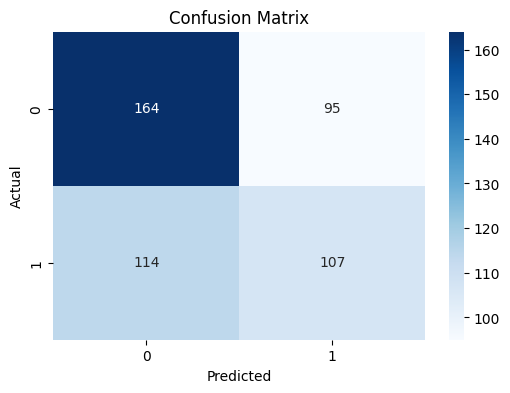

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Feature Importance Analysis

In [ ]:
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False

)

feature_importance

,Feature,Importance
1,total_spent,0.312720
2,avg_order_value,0.293903
3,avg_delivery_days,0.169513
5,avg_rating,0.131351
0,total_orders,0.052432
4,return_rate,0.040081


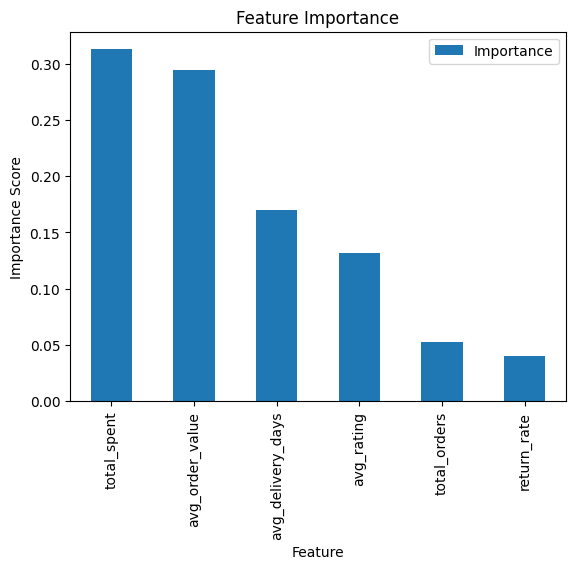

In [ ]:
feature_importance.plot(

    x='Feature',

    y='Importance',

    kind='bar'

)

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.show()

In [ ]:
# Save Trained Model

with open('model.pkl', 'wb') as file:

    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


In [ ]:
# Save Metrics

metrics = {

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1)

}

with open('metrics.json', 'w') as file:

    json.dump(

        metrics,

        file,

        indent=4

    )

print("Metrics saved successfully")

Metrics saved successfully
